## Approve or reject

The primary role of an interrupt is to implement a Human-in-the-Loop (HITL) checkpoint. This mechanism forces the system to stop and wait for human review before executing any critical action, ensuring a person validates the outcome of tha automated process.

The below healthcare approval workflow, the langgraph framework uses interrupts to model points where external human or organizational approval is required before the process can continue.

## Specifically:

Insurance Approval: After the doctor_review is complete, the workflow enters the insurance_review node, which immediately issues an interrupt("Awaiting insurance company approval..."). This effectively pauses the graph to wait for an external actor (like a human user or an integration with an insurance API) to provide the necessary approval by updating the graph's state (setting insurance_approval to True or False).

Hospital Admin Confirmation: Similarly, the admin_review node issues an interrupt("Awaiting hospital admin confirmation..."). This pauses the graph again, requiring the hospital administrator's confirmation (by updating the admin_confirmation state) before the process can move to the finalization step.

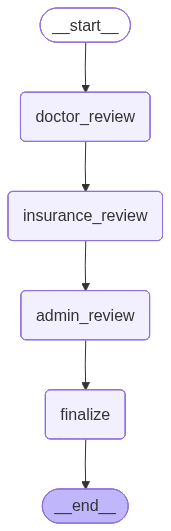

In [83]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

# ---------------------
# Define State Schema
# ---------------------
class HealthcareState(TypedDict):
    case_details: str
    doctor_decision: Optional[bool]
    insurance_approval: Optional[bool]
    admin_confirmation: Optional[bool]
    result: Annotated[list[str], add_messages]

# ---------------------
# Define Graph Nodes
# ---------------------
def doctor_review(state: HealthcareState):
    print(" Doctor reviewing case...")
    return {"result": ["Doctor recommends surgery"], "doctor_decision": True}

def insurance_review(state: HealthcareState):
    print(" Insurance approval pending...")
    return interrupt("Awaiting insurance company approval...")

def admin_review(state: HealthcareState):
    print(" Hospital admin review pending...")
    return interrupt("Awaiting hospital admin confirmation...")

def finalize(state: HealthcareState):
    if state.get("insurance_approval") and state.get("admin_confirmation"):
        msg = " Surgery authorized and scheduled!"
    else:
        msg = " Surgery request denied or incomplete approvals."
    print(msg)
    return {"result": [msg]}

# ---------------------
# Build Graph
# ---------------------
graph = StateGraph(HealthcareState)
graph.add_node("doctor_review", doctor_review)
graph.add_node("insurance_review", insurance_review)
graph.add_node("admin_review", admin_review)
graph.add_node("finalize", finalize)

graph.add_edge(START, "doctor_review")
graph.add_edge("doctor_review", "insurance_review")
graph.add_edge("insurance_review", "admin_review")
graph.add_edge("admin_review", "finalize")
graph.add_edge("finalize", END)

memory = MemorySaver()
compiled_graph = graph.compile(checkpointer=memory)

graph.compile(checkpointer=memory)

In [84]:

# ---------------------
# Simulate Execution
# ---------------------
config = {"configurable": {"thread_id": "case_001"}}

# Step 1 - Start case
initial = compiled_graph.invoke({"case_details": "Patient requires knee surgery"}, config=config)
print("\n--- INTERRUPT 1 ---")
print(initial["__interrupt__"])

 Doctor reviewing case...
 Insurance approval pending...

--- INTERRUPT 1 ---
[Interrupt(value='Awaiting insurance company approval...', id='bbc068bc8a9d4827c4fdd705d6a466d1')]


In [85]:
# Resume with insurance approval granted
res1 = compiled_graph.invoke(Command(resume={"insurance_approval": False}), config=config)
print("\n--- INTERRUPT 2 ---")
print(res1["__interrupt__"])


 Insurance approval pending...
 Hospital admin review pending...

--- INTERRUPT 2 ---
[Interrupt(value='Awaiting hospital admin confirmation...', id='d89a459be5fd6af4ada534f57b34edfc')]


In [86]:
# Resume with admin approval granted
res2 = compiled_graph.invoke(Command(resume={"admin_confirmation": True}), config=config)
print("\n--- FINAL OUTPUT ---")
print(res2["result"])


 Hospital admin review pending...
 Surgery request denied or incomplete approvals.

--- FINAL OUTPUT ---
[HumanMessage(content='Doctor recommends surgery', additional_kwargs={}, response_metadata={}, id='0004276c-cb32-4103-ac00-2b78dde73851'), HumanMessage(content=' Surgery request denied or incomplete approvals.', additional_kwargs={}, response_metadata={}, id='ce318b13-b887-48d9-be2d-edce21d49884')]
